# Maximum Clique Problem — Branch & Bound con Relajación LP

## Proyecto de Investigación — Optimización en Ingeniería

**Integrantes:** Ricardo Riveros, Gonzalo Ahumada  

Este notebook formula el Maximum Clique Problem (MCP) como un programa lineal entero binario,
implementa la relajación LP como cota superior, y utiliza el framework **PyBnB** para
resolver el problema mediante Branch & Bound.

## 1. Importación de Librerías

In [12]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import linprog
import pybnb
import time
import os
import urllib.request

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print(f"pybnb version: {pybnb.__version__}")

pybnb version: 0.6.2


## 2. Configuración y Carga de la Instancia DIMACS

Configurar la variable `INSTANCE_SOURCE` con:  
- Una **URL** directa a un archivo `.clq` (se descarga automáticamente), o  
- Una **ruta local** a un archivo `.clq` ya descargado.  

El catálogo de instancias está disponible en: https://iridia.ulb.ac.be/~fmascia/maximum_clique/DIMACS-benchmark  

Opcionalmente, indicar el óptimo conocido (`KNOWN_OPTIMUM`) para comparar resultados. Si no se conoce, dejar en `None`.

In [13]:
# ============================================================
# CONFIGURACIÓN — Modificar aquí para cambiar de instancia
# ============================================================
INSTANCE_SOURCE = 'http://iridia.ulb.ac.be/~fmascia/files/DIMACS/C125.9.clq'
KNOWN_OPTIMUM = 34        # Poner None si no se conoce (Best know solution)
TIME_LIMIT = 300           # Límite de tiempo en segundos
# ============================================================

# Resolver la fuente de la instancia
if INSTANCE_SOURCE.startswith('http://') or INSTANCE_SOURCE.startswith('https://'):
    instance_filename = os.path.basename(INSTANCE_SOURCE)
    if not os.path.exists(instance_filename):
        print(f"Descargando {instance_filename} desde {INSTANCE_SOURCE} ...")
        urllib.request.urlretrieve(INSTANCE_SOURCE, instance_filename)
        print(f"Descarga completada: {instance_filename}")
    else:
        print(f"Instancia encontrada localmente: {instance_filename}")
else:
    instance_filename = INSTANCE_SOURCE
    if not os.path.exists(instance_filename):
        raise FileNotFoundError(f"No se encontró el archivo: {instance_filename}")
    print(f"Usando instancia local: {instance_filename}")

Instancia encontrada localmente: C125.9.clq


In [14]:
def parse_dimacs(filename):
    """Parsea un archivo DIMACS .clq y retorna un grafo NetworkX."""
    G = nx.Graph()
    with open(filename, 'r') as f:
        for line in f:
            if line.startswith('p'):
                parts = line.split()
                n_vertices = int(parts[2])
                G.add_nodes_from(range(1, n_vertices + 1))
            elif line.startswith('e'):
                parts = line.split()
                u, v = int(parts[1]), int(parts[2])
                G.add_edge(u, v)
    return G

G = parse_dimacs(instance_filename)
n = G.number_of_nodes()
m = G.number_of_edges()
density = 2 * m / (n * (n - 1))
instance_name = os.path.splitext(os.path.basename(instance_filename))[0]

print(f"Instancia: {instance_name}")
print(f"Nodos: {n}")
print(f"Aristas: {m}")
print(f"Densidad: {density:.4f}")
print(f"Aristas complemento (restricciones): {n*(n-1)//2 - m}")
if KNOWN_OPTIMUM:
    print(f"Óptimo conocido: ω(G) = {KNOWN_OPTIMUM}")

Instancia: C125.9
Nodos: 125
Aristas: 6963
Densidad: 0.8985
Aristas complemento (restricciones): 787
Óptimo conocido: ω(G) = 34


## 3. Formulación del Modelo ILP

El Maximum Clique Problem se formula como un programa lineal entero binario:

$$\max \quad z = \sum_{i \in V} x_i$$

$$\text{s.a.} \quad x_i + x_j \leq 1, \quad \forall (i,j) \in \bar{E}$$

$$x_i \in \{0, 1\}, \quad \forall i \in V$$

Donde $\bar{E}$ es el conjunto de no-aristas (aristas del grafo complemento).

La **relajación LP** reemplaza $x_i \in \{0,1\}$ por $0 \leq x_i \leq 1$, proporcionando
una cota superior $z^*_{LP} \geq z^*_{ILP}$ que se utiliza para podar ramas del árbol B&B.

In [15]:
# Construir las estructuras del modelo ILP
nodes_list = sorted(G.nodes())
node_to_idx = {node: i for i, node in enumerate(nodes_list)}

# Conjunto de no-aristas (restricciones x_i + x_j <= 1)
complement_edges = []
for i in range(len(nodes_list)):
    for j in range(i + 1, len(nodes_list)):
        if not G.has_edge(nodes_list[i], nodes_list[j]):
            complement_edges.append((i, j))

# Matriz de restricciones A_ub y vector b_ub (para scipy.linprog)
A_ub = np.zeros((len(complement_edges), n))
b_ub = np.ones(len(complement_edges))
for k, (i, j) in enumerate(complement_edges):
    A_ub[k, i] = 1
    A_ub[k, j] = 1

# Coeficientes de la función objetivo (linprog minimiza, así que negamos)
c_obj = -np.ones(n)

print(f"Variables de decisión: {n}")
print(f"Restricciones de adyacencia: {len(complement_edges)}")

Variables de decisión: 125
Restricciones de adyacencia: 787


## 4. Relajación LP del Nodo Raíz

Antes de ejecutar el B&B, analizamos la relajación LP del problema completo
para entender la brecha de integralidad (*integrality gap*).

In [16]:
root_lp = linprog(c_obj, A_ub=A_ub, b_ub=b_ub,
                  bounds=[(0, 1)] * n, method='highs')
root_ub = -root_lp.fun
root_solution = root_lp.x

n_frac = sum(1 for x in root_solution if 1e-6 < x < 1 - 1e-6)

print(f"Cota superior LP (raíz): {root_ub:.2f}")
if KNOWN_OPTIMUM:
    print(f"Óptimo entero conocido:  {KNOWN_OPTIMUM}")
    print(f"Brecha de integralidad:  {root_ub - KNOWN_OPTIMUM:.2f} ({((root_ub - KNOWN_OPTIMUM)/KNOWN_OPTIMUM)*100:.1f}%)")
print(f"Variables fraccionarias:  {n_frac} de {n}")
print(f"Variables enteras:        {n - n_frac} de {n}")

Cota superior LP (raíz): 62.50
Óptimo entero conocido:  34
Brecha de integralidad:  28.50 (83.8%)
Variables fraccionarias:  125 de 125
Variables enteras:        0 de 125


## 5. Definición del Problema para PyBnB

PyBnB requiere definir una clase que herede de `pybnb.Problem` e implemente:
- `sense()`: dirección de optimización (maximizar)
- `objective()`: valor de la función objetivo de la solución actual
- `bound()`: cota superior del subproblema (relajación LP)
- `save_state()` / `load_state()`: gestión del estado en cada nodo del árbol
- `branch()`: genera los subproblemas hijos (ramificación)

In [17]:
class MaxCliqueProblem(pybnb.Problem):
    """Maximum Clique Problem resuelto con B&B y relajación LP."""

    def __init__(self, n_vars, c_obj, A_ub, b_ub):
        self.n = n_vars
        self.c_obj = c_obj
        self.A_ub = A_ub
        self.b_ub = b_ub

        # Estado del nodo: cotas de cada variable [lb, ub]
        self.bounds_lb = np.zeros(self.n)
        self.bounds_ub = np.ones(self.n)

        # Resultado de la relajación LP del nodo actual
        self._lp_solution = None
        self._lp_obj = self.infeasible_objective()
        self._lp_feasible = False

        # Estadísticas
        self.lp_solves = 0
        self.history = []

    def sense(self):
        return pybnb.maximize

    def objective(self):
        """Retorna el valor objetivo si la solución LP es entera, sino infeasible."""
        if not self._lp_feasible:
            return self.infeasible_objective()
        x = self._lp_solution
        if all(xi < 1e-6 or xi > 1 - 1e-6 for xi in x):
            return float(sum(1 for xi in x if xi > 0.5))
        return self.infeasible_objective()

    def bound(self):
        """Resuelve la relajación LP y retorna la cota superior."""
        bounds = [(self.bounds_lb[i], self.bounds_ub[i]) for i in range(self.n)]
        result = linprog(self.c_obj, A_ub=self.A_ub, b_ub=self.b_ub,
                         bounds=bounds, method='highs')
        self.lp_solves += 1

        if result.success:
            self._lp_feasible = True
            self._lp_solution = result.x
            self._lp_obj = -result.fun
            return self._lp_obj
        else:
            self._lp_feasible = False
            self._lp_solution = None
            return self.infeasible_objective()

    def save_state(self, node):
        node.state = (self.bounds_lb.copy(), self.bounds_ub.copy())

    def load_state(self, node):
        self.bounds_lb, self.bounds_ub = node.state

    def branch(self):
        """Selecciona la variable fraccionaria más cercana a 0.5 y ramifica."""
        if not self._lp_feasible or self._lp_solution is None:
            return

        x = self._lp_solution
        # Buscar variable fraccionaria más cercana a 0.5
        best_var = None
        best_dist = float('inf')
        for i in range(self.n):
            if 1e-6 < x[i] < 1 - 1e-6:
                dist = abs(x[i] - 0.5)
                if dist < best_dist:
                    best_dist = dist
                    best_var = i

        if best_var is None:
            return

        # Hijo 1: x_k = 1 (incluir vértice en el clique)
        child1 = pybnb.Node()
        lb1, ub1 = self.bounds_lb.copy(), self.bounds_ub.copy()
        lb1[best_var] = 1.0
        ub1[best_var] = 1.0
        child1.state = (lb1, ub1)
        yield child1

        # Hijo 2: x_k = 0 (excluir vértice del clique)
        child2 = pybnb.Node()
        lb2, ub2 = self.bounds_lb.copy(), self.bounds_ub.copy()
        lb2[best_var] = 0.0
        ub2[best_var] = 0.0
        child2.state = (lb2, ub2)
        yield child2

    def notify_new_best_node(self, node, current):
        """Registra el progreso cada vez que se encuentra una mejor solución."""
        self.history.append((
            self.lp_solves,
            node.objective
        ))

## 6. Ejecución del Branch & Bound

In [18]:
problem = MaxCliqueProblem(n, c_obj, A_ub, b_ub)
solver = pybnb.Solver(comm=None)

print(f"Resolviendo {instance_name} con Branch & Bound (PyBnB)...")
print("=" * 60)

start_time = time.time()
results = solver.solve(
    problem,
    time_limit=TIME_LIMIT,
    log_interval_seconds=5.0,
    queue_strategy='depth'
)
elapsed_time = time.time() - start_time

print(f"\n{'=' * 60}")
print(f"RESULTADOS — {instance_name}")
print(f"{'=' * 60}")
print(f"Estado de la solución:  {results.solution_status}")
print(f"Condición de término:   {results.termination_condition}")
print(f"Clique encontrado:      {int(results.objective)}")
if KNOWN_OPTIMUM:
    print(f"Óptimo conocido:        {KNOWN_OPTIMUM}")
    gap = (KNOWN_OPTIMUM - results.objective) / KNOWN_OPTIMUM * 100
    print(f"Gap de optimalidad:     {gap:.1f}%")
print(f"Cota superior final:    {results.bound:.2f}")
print(f"Nodos B&B explorados:   {results.nodes}")
print(f"Relajaciones LP:        {problem.lp_solves}")
print(f"Tiempo de ejecución:    {elapsed_time:.2f} s")

Resolviendo C125.9 con Branch & Bound (PyBnB)...

Using non-default solver options:
 - log_interval_seconds: 5.0 (default: 1.0)
 - queue_strategy: depth (default: bound)
 - time_limit: 300 (default: None)

Starting branch & bound solve:
 - dispatcher pid: 89787 (daniel-munoz-mbp-69)
 - worker processes: 1
--------------------------------------------------------------------------------------------------------------------------
         Nodes        |                      Objective Bounds                       |              Work              
      Expl    Unexpl  |      Incumbent           Bound    Rel. Gap         Abs. Gap | Time (s)  Nodes/Sec Imbalance   Idle
         0         1  |           -inf             inf         inf%             inf |      0.0       0.00     0.00%      0
         1         2  |           -inf            62.5         inf%             inf |      0.0     284.65     0.00%      0
*       17        16  |             26            62.5  140.384615%            36.5

In [19]:
# Recuperar la solución óptima
if results.best_node is not None:
    problem.load_state(results.best_node)
    # Resolver LP una última vez para obtener el vector solución
    problem.bound()
    solution = problem._lp_solution
    clique_size = int(results.objective)

    clique_nodes = [nodes_list[i] for i in range(n) if solution[i] > 0.5]
    print(f"Vértices del clique ({clique_size}): {sorted(clique_nodes)}")

    # Verificar validez
    subgraph = G.subgraph(clique_nodes)
    expected = clique_size * (clique_size - 1) // 2
    actual = subgraph.number_of_edges()
    print(f"\nVerificación: {actual}/{expected} aristas")
    print(f"¿Es clique válido? {'Sí ✓' if actual == expected else 'No ✗'}")
else:
    clique_size = 0
    clique_nodes = []
    solution = None
    print("No se encontró solución factible.")

Vértices del clique (34): [1, 2, 5, 7, 9, 11, 17, 18, 19, 25, 29, 31, 34, 40, 44, 45, 47, 48, 49, 70, 71, 77, 79, 91, 92, 98, 101, 110, 114, 115, 117, 121, 122, 125]

Verificación: 561/561 aristas
¿Es clique válido? Sí ✓


## 7. Tabla de Resultados

In [20]:
results_data = {
    'Métrica': [
        'Instancia',
        'Nodos del grafo (|V|)',
        'Aristas del grafo (|E|)',
        'Densidad del grafo',
        'No-aristas (restricciones)',
        'Cota superior LP (raíz)',
        'Óptimo conocido ω(G)',
        'Solución encontrada',
        'Gap de integralidad LP (%)',
        'Estado de la solución',
        'Condición de término',
        'Tiempo de ejecución (s)',
        'Nodos B&B explorados',
        'Relajaciones LP resueltas'
    ],
    'Valor': [
        instance_name,
        n,
        m,
        f'{density:.4f}',
        len(complement_edges),
        f'{root_ub:.2f}',
        KNOWN_OPTIMUM if KNOWN_OPTIMUM else 'N/A',
        clique_size,
        f'{((root_ub - KNOWN_OPTIMUM) / KNOWN_OPTIMUM) * 100:.1f}' if KNOWN_OPTIMUM else 'N/A',
        str(results.solution_status),
        str(results.termination_condition),
        f'{elapsed_time:.2f}',
        results.nodes,
        problem.lp_solves
    ]
}

df_results = pd.DataFrame(results_data)
print(df_results.to_string(index=False))

                   Métrica      Valor
                 Instancia     C125.9
     Nodos del grafo (|V|)        125
   Aristas del grafo (|E|)       6963
        Densidad del grafo     0.8985
No-aristas (restricciones)        787
   Cota superior LP (raíz)      62.50
      Óptimo conocido ω(G)         34
       Solución encontrada         34
Gap de integralidad LP (%)       83.8
     Estado de la solución   feasible
      Condición de término time_limit
   Tiempo de ejecución (s)     300.00
      Nodos B&B explorados     232953
 Relajaciones LP resueltas     232954


## 8. Gráficos

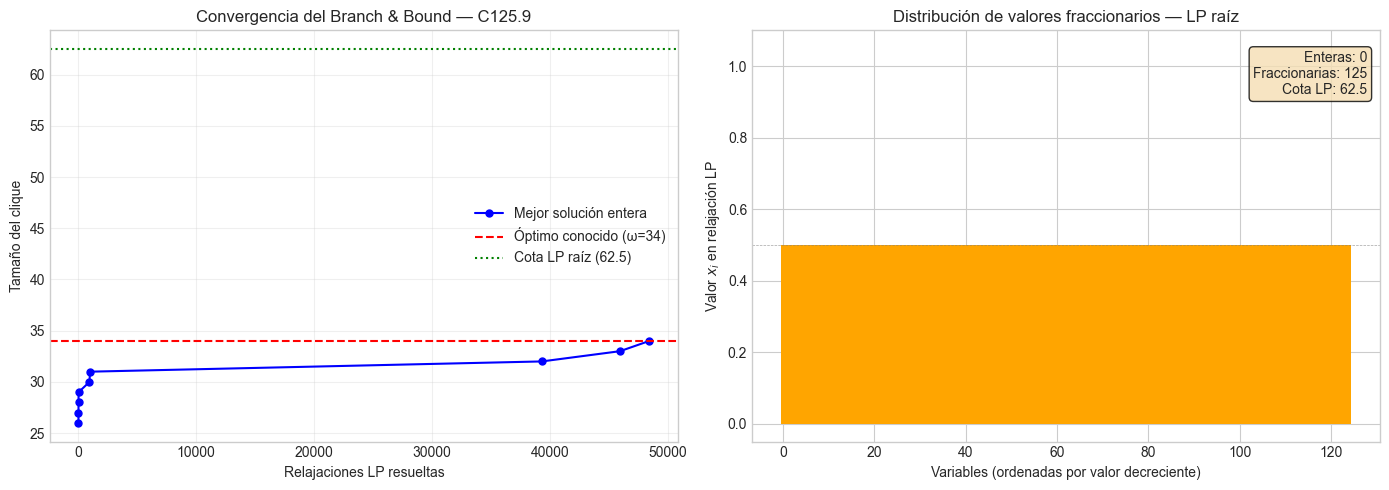

Figura guardada: resultados_bb_C125.9.png


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: Convergencia del B&B ---
ax1 = axes[0]
if problem.history:
    hist_lps = [h[0] for h in problem.history]
    hist_obj = [h[1] for h in problem.history]
    ax1.plot(hist_lps, hist_obj, 'b-o', markersize=5, linewidth=1.5,
             label='Mejor solución entera')
if KNOWN_OPTIMUM:
    ax1.axhline(y=KNOWN_OPTIMUM, color='r', linestyle='--', linewidth=1.5,
                label=f'Óptimo conocido (ω={KNOWN_OPTIMUM})')
ax1.axhline(y=root_ub, color='g', linestyle=':', linewidth=1.5,
            label=f'Cota LP raíz ({root_ub:.1f})')
ax1.set_xlabel('Relajaciones LP resueltas')
ax1.set_ylabel('Tamaño del clique')
ax1.set_title(f'Convergencia del Branch & Bound — {instance_name}')
ax1.legend(loc='center right')
ax1.grid(True, alpha=0.3)

# --- Gráfico 2: Distribución de valores LP raíz ---
ax2 = axes[1]
sorted_vals = np.sort(root_solution)[::-1]
colors_bar = ['red' if v > 0.99 else ('orange' if v > 0.01 else 'lightblue')
              for v in sorted_vals]
ax2.bar(range(n), sorted_vals, color=colors_bar, edgecolor='none', width=1.0)
ax2.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
ax2.set_xlabel('Variables (ordenadas por valor decreciente)')
ax2.set_ylabel('Valor $x_i$ en relajación LP')
ax2.set_title('Distribución de valores fraccionarios — LP raíz')
ax2.set_ylim(-0.05, 1.1)
ax2.text(0.98, 0.95,
         f'Enteras: {n - n_frac}\nFraccionarias: {n_frac}\nCota LP: {root_ub:.1f}',
         transform=ax2.transAxes, ha='right', va='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig(f'resultados_bb_{instance_name}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figura guardada: resultados_bb_{instance_name}.png")

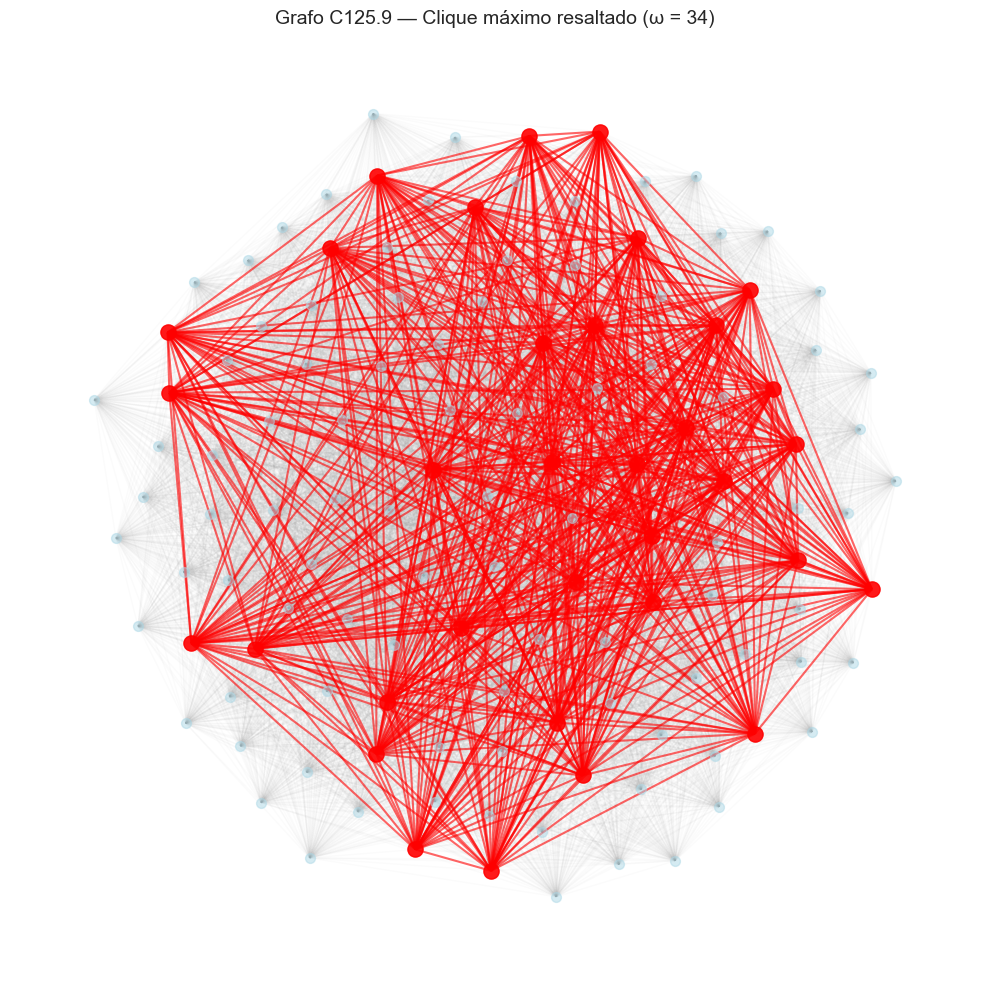

Figura guardada: grafo_clique_C125.9.png


In [22]:
# --- Gráfico 3: Visualización del grafo con el clique resaltado ---
if solution is not None and clique_size > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    clique_set = set(clique_nodes)
    non_clique = [v for v in G.nodes() if v not in clique_set]

    pos = nx.spring_layout(G, seed=42, k=0.3)

    clique_edges = [(u, v) for u, v in G.edges() if u in clique_set and v in clique_set]
    other_edges = [(u, v) for u, v in G.edges() if u not in clique_set or v not in clique_set]

    nx.draw_networkx_edges(G, pos, edgelist=other_edges, alpha=0.03,
                           edge_color='gray', ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=clique_edges, alpha=0.6,
                           edge_color='red', width=1.5, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=non_clique,
                           node_color='lightblue', node_size=50, alpha=0.5, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=clique_nodes,
                           node_color='red', node_size=120, alpha=0.9, ax=ax)

    ax.set_title(f'Grafo {instance_name} — Clique máximo resaltado (ω = {clique_size})',
                 fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'grafo_clique_{instance_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figura guardada: grafo_clique_{instance_name}.png")

## 9. Resumen y Conclusiones del Experimento

### Observaciones principales:

1. **Brecha de integralidad:** La relajación LP proporciona una cota superior significativamente mayor que el óptimo entero, lo cual es una característica conocida del MCP en grafos densos.

2. **Eficacia del B&B:** El framework PyBnB gestiona eficientemente el árbol de búsqueda, aplicando podas por cota basadas en la relajación LP de cada subproblema.

3. **Complejidad computacional:** El número de nodos explorados y el tiempo de ejecución evidencian la naturaleza NP-dura del problema.

4. **Validación:** La solución encontrada corresponde a un clique válido verificable en el grafo original.